# iQuHack 2026 - Quantum Entanglement Distillation Game

In this game, you design quantum circuits to distill noisy Bell pairs and claim edges in a network.

**Game Flow**: Register -> Select Starting Node -> Design Circuits -> Claim Edges -> Score Points

In [ ]:
%pip install qiskit

Note: you may need to restart the kernel to use updated packages.


In [1]:
%pip install -r requirements.txt

Note: you may need to restart the kernel to use updated packages.


In [2]:
from client import GameClient
from visualization import GraphTool
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
import json
from pathlib import Path
from qiskit.circuit.classical import expr

## Session Management

Save/load your session to avoid re-registering.

In [3]:
SESSION_FILE = Path("session.json")

def save_session(client):
    if client.api_token:
        with open(SESSION_FILE, "w") as f:
            json.dump({"api_token": client.api_token, "player_id": client.player_id, "name": client.name}, f)
        print(f"Session saved.")

def load_session():
    if not SESSION_FILE.exists():
        return None
    with open(SESSION_FILE) as f:
        data = json.load(f)
    client = GameClient(api_token=data.get("api_token"))
    client.player_id = data.get("player_id")
    client.name = data.get("name")
    status = client.get_status()
    if status:
        print(f"Resumed: {client.player_id} | Score: {status.get('score', 0)} | Budget: {status.get('budget', 0)}")
        return client
    return None

In [41]:
# Try to resume existing session
client = load_session()

if not client:
    print("No saved session. Register below.")

Resumed: 453 | Score: 17 | Budget: 26


## Step 1: Register

Skip this if you resumed a session above.

In [54]:
if client and client.api_token:
    print(f"Already registered as {client.player_id}")
else:
    client = GameClient()
    
    # CHANGE THESE to your unique values
    PLAYER_ID = "453"
    PLAYER_NAME = "Shane"
    
    result = client.register(PLAYER_ID, PLAYER_NAME, location="remote")
    
    if result.get("ok"):
        print(f"Registered! Token: {client.api_token[:20]}...")
        candidates = result["data"].get("starting_candidates", [])
        print(f"\nStarting candidates ({len(candidates)}):")
        for c in candidates:
            print(f"  - {c['node_id']}: {c['utility_qubits']} qubits, +{c['bonus_bell_pairs']} bonus")
        save_session(client)
    else:
        print(f"Failed: {result.get('error', {}).get('message')}")

Already registered as 453


## Step 2: Select Starting Node

In [55]:
status = client.get_status()

if status.get('starting_node'):
    print(f"Starting node: {status['starting_node']}")
    print(f"Budget: {status['budget']} | Score: {status['score']}")
else:
    print("Select a starting node from the candidates shown above.")
    # Uncomment and modify:
    result = client.select_starting_node("Dalian, China")
    print(result)

Starting node: Dalian, China
Budget: 14 | Score: 17


## Step 3: Explore the Network

In [8]:
# client.print_status()

In [9]:
# Visualize the network (focused around your nodes)
# viz = GraphTool(client.get_cached_graph())
# owned = set(client.get_status().get('owned_nodes', []))
# viz.render(owned)

## Step 4: Design a Distillation Circuit

For N Bell pairs, qubits are paired outside-in:
- Pair 0: qubits {0, 2N-1}
- Pair 1: qubits {1, 2N-2}
- ...
- Final pair: qubits {N-1, N}

Design a circuit that improves fidelity through LOCC operations.

In [17]:
def storage(qc,flag):
    qc.reset(0)  # Reuse qubit 0 for flag
    with qc.if_test((qc.clbits[0], 1)):
        qc.x(0)
    with qc.if_test((qc.clbits[1], 1)):
        qc.x(0)
    qc.measure(0, flag)

In [34]:
qc = QuantumCircuit(4, 2)
qc.num_qubits

4

# Useful information starts here

In [7]:
def create_x():
    qubit_pairs = 2
    qc = QuantumCircuit(qubit_pairs*2,3)
    
    qc.cx(1, 0)
    qc.cx(2, 3)

    qc.measure(0,0)
    qc.measure(3, 1)
    condition1 = expr.bit_xor(expr.lift(qc.clbits[0]),expr.lift(qc.clbits[1]))
    qc.store(qc.clbits[2],condition1)   
    return qc
    
def create_z():
    qubit_pairs = 2
    qc = QuantumCircuit(qubit_pairs*2, 3)

    qc.cx(0 ,qubit_pairs-1)
    qc.h(0)
    qc.cx(qubit_pairs*2-1,qubit_pairs)  
    qc.h(qubit_pairs*2-1)     

    qc.measure(0, 0)
    qc.measure(3, 1)

    condition1 = expr.bit_xor(expr.lift(qc.clbits[0]),expr.lift(qc.clbits[1]))
    qc.store(qc.clbits[2],condition1)
    return qc


def create_id():
    qc = QuantumCircuit(2, 1)
    return qc


def create_xz():
    qubit_pairs = 3
    flag = 2
    qc = QuantumCircuit(qubit_pairs*2,qubit_pairs*2)
    
    qc.cx(2,1)
    qc.cx(0,1)
    qc.h(0)
    
    qc.cx(3,4)
    qc.cx(5,4)
    qc.h(5)

    
    qc.measure(0,0)
    qc.measure(1,1)
    qc.measure(4,4)
    qc.measure(5,5)


    condition1 = expr.bit_xor(expr.lift(qc.clbits[0]),expr.lift(qc.clbits[5]))
    condition2 = expr.bit_xor(expr.lift(qc.clbits[1]),expr.lift(qc.clbits[4]))
    qc.store(qc.clbits[flag],condition2 and condition1)
    return qc

# Distillation Circuits

## Common

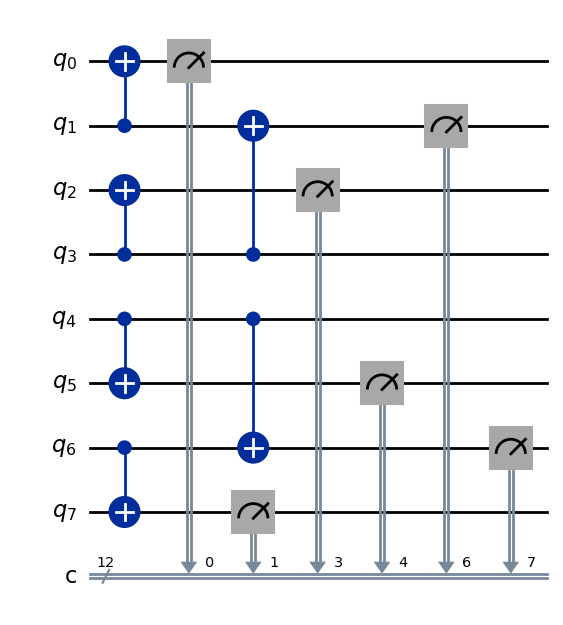

In [71]:
def distillation_circuit_1():
    "Basically, the identity"
    qc = QuantumCircuit(2,1)

def distillation_circuit_2(t):
    """Example distillation circuit template for 2 Bell pairs."""
    """Minimum case"""
    "t = z or x"
    if t == "z":
        q = create_z()
    elif t == "x":
        q = create_x()
    num_bell_pairs = 2
    qr = QuantumRegister(num_bell_pairs*2, 'q')  # 4 qubits for 2 Bell pairs
    cr = ClassicalRegister(num_bell_pairs*3, 'c')  # Classical bits for measurements + flag
    qc = QuantumCircuit(qr, cr)
    
    
    qc.compose(q, qubits=[0,1,2,3], clbits=range(3),inplace=True)
    return qc

def distillation_circuit_4(t):
    """Example distillation circuit template for 2 Bell pairs."""
    "t = z or x"
    if t == "z":
        q = create_z()
    elif t == "x":
        q = create_x()
    num_bell_pairs = 4
    qr = QuantumRegister(num_bell_pairs*2, 'q')  # 4 qubits for 2 Bell pairs
    cr = ClassicalRegister(num_bell_pairs*3, 'c')  # Classical bits for measurements + flag
    qc = QuantumCircuit(qr, cr)
    
    ##ORDERING IS IMPORTANT HERE
    qc.compose(q,qubits = [0,1,6,7],clbits=range(3),inplace=True)
    qc.compose(q, qubits=[2,3,4,5], clbits=range(3,6),inplace=True)
    qc.compose(q, qubits=[1,3,4,6], clbits=range(6,9),inplace=True)

    false1 = expr.bit_or(expr.lift(qc.clbits[2]),expr.lift(qc.clbits[5]))
    qc.store(qc.clbits[9],false1) 
    false_condition = expr.bit_or(expr.lift(qc.clbits[8]),expr.lift(qc.clbits[9]))
    qc.store(qc.clbits[10],false_condition)

    return qc

def distillation_circuit_8(t):
    """Example distillation circuit template for 2 Bell pairs."""
    "t = z or x"
    if t == "z":
        q = create_z()
    elif t == "x":
        q = create_x()
    num_bell_pairs = 8
    qr = QuantumRegister(num_bell_pairs*2, 'q')  # 4 qubits for 2 Bell pairs
    cr = ClassicalRegister(27, 'c')  # Classical bits for measurements + flag
    qc = QuantumCircuit(qr, cr)
    
    ##ORDERING IS IMPORTANT HERE
    #Stage 1
    qc.compose(q, qubits=[0,1,14,15], clbits=range(3),inplace=True)
    qc.compose(q, qubits=[2,3,12,13], clbits=range(3,6),inplace=True)
    qc.compose(q, qubits=[4,5,10,11], clbits=range(6,9),inplace=True)
    qc.compose(q, qubits=[6,7,8,9], clbits=range(9,12),inplace=True)
    #Stage 2
    qc.compose(q, qubits=[1,3,12,14], clbits=range(12,15),inplace=True)
    qc.compose(q, qubits=[5,7,8,10], clbits=range(15,18),inplace=True)
    #Stage 3
    qc.compose(q, qubits=[3,7,8,12], clbits=range(18,21),inplace=True)

    #COMPARISONS
    false1 = expr.bit_or(expr.lift(qc.clbits[2]),expr.lift(qc.clbits[5]))
    qc.store(qc.clbits[21],false1) 
    false2 = expr.bit_or(expr.lift(qc.clbits[8]),expr.lift(qc.clbits[11]))
    qc.store(qc.clbits[22],false2)
    false3 = expr.bit_or(expr.lift(qc.clbits[14]),expr.lift(qc.clbits[17]))
    qc.store(qc.clbits[23],false3) 

    #COMPARISONS STAGE 2
    false4 = expr.bit_or(expr.lift(qc.clbits[21]),expr.lift(qc.clbits[22]))
    qc.store(qc.clbits[24],false4)
    false5 = expr.bit_or(expr.lift(qc.clbits[23]),expr.lift(qc.clbits[20]))
    qc.store(qc.clbits[25],false5)

    false_condition = expr.bit_or(expr.lift(qc.clbits[24]),expr.lift(qc.clbits[25]))
    qc.store(qc.clbits[26],false_condition)

    return qc

circuit = distillation_circuit_4("x") #create_id() #create_x() #create_distillation_circuit()

circuit.draw("mpl")





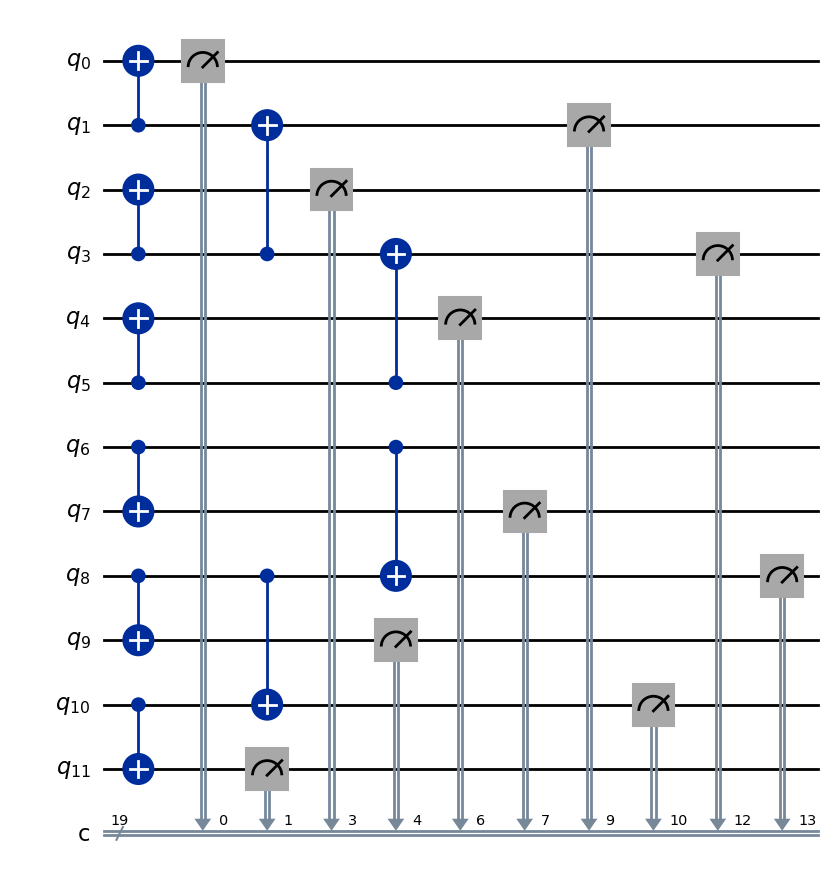

In [72]:
def distillation_circuit_6(t):
    """Example distillation circuit template for 2 Bell pairs."""
    "t = z or x"
    if t == "z":
        q = create_z()
    elif t == "x":
        q = create_x()
    num_bell_pairs = 6
    qr = QuantumRegister(num_bell_pairs*2, 'q')  # 4 qubits for 2 Bell pairs
    cr = ClassicalRegister(19, 'c')  # Classical bits for measurements + flag
    qc = QuantumCircuit(qr, cr)
    
    qz = create_z()
    qx = create_x()
    ##ORDERING IS IMPORTANT HERE
    #Stage 1
    qc.compose(qx, qubits=[0,1,10,11], clbits=range(3),inplace=True)
    qc.compose(qx, qubits=[2,3,8,9], clbits=range(3,6),inplace=True)
    qc.compose(qx, qubits=[4,5,6,7], clbits=range(6,9),inplace=True)
    #Stage 2
    qc.compose(qx, qubits=[1,3,8,10], clbits=range(9,12),inplace=True)
    #Stage 3
    qc.compose(qx, qubits=[3,5,6,8], clbits=range(12,15),inplace=True)

    #COMPARISONS
    false1 = expr.bit_or(expr.lift(qc.clbits[2]),expr.lift(qc.clbits[5]))
    qc.store(qc.clbits[15],false1) 
    false2 = expr.bit_or(expr.lift(qc.clbits[8]),expr.lift(qc.clbits[11]))
    qc.store(qc.clbits[16],false2)

    #COMPARISONS STAGE 2
    false4 = expr.bit_or(expr.lift(qc.clbits[15]),expr.lift(qc.clbits[16]))
    qc.store(qc.clbits[17],false4)


    false_condition = expr.bit_or(expr.lift(qc.clbits[14]),expr.lift(qc.clbits[17]))
    qc.store(qc.clbits[18],false_condition)

    return qc

circuit = distillation_circuit_6("z") #create_id() #create_x() #create_distillation_circuit()

circuit.draw("mpl")

## Rare

In [88]:
def distillation_circuit_3():
    """Example distillation circuit template for 2 Bell pairs."""
    num_bell_pairs = 3
    qr = QuantumRegister(num_bell_pairs*2, 'q')  # 4 qubits for 2 Bell pairs
    cr = ClassicalRegister(7, 'c')  # Classical bits for measurements + flag
    qc = QuantumCircuit(qr, cr)

    qc.cx(2,1)
    qc.cx(1,0)
    qc.cx(3,4)
    qc.cx(4,5)

    qc.measure(0,0)
    qc.measure(1,1)
    qc.measure(4,2)
    qc.measure(5,3)

    condition1 = expr.bit_xor(expr.lift(qc.clbits[0]),expr.lift(qc.clbits[1]))
    qc.store(qc.clbits[4],condition1) 
    condition2 = expr.bit_xor(expr.lift(qc.clbits[2]),expr.lift(qc.clbits[3]))
    qc.store(qc.clbits[5],condition2) 

    false_condition = expr.bit_or(expr.lift(qc.clbits[4]),expr.lift(qc.clbits[5]))
    qc.store(qc.clbits[6],false_condition)

    return qc

In [37]:
def aaron_circuit_4pairs():
    qc = QuantumCircuit(8, 7)
    for i in range(3):
        qc.cx(3, i)
        qc.cx(4, 7-i)
    for i in range(3):
        qc.measure(i, i)
        qc.measure(7-i, 3+i)
    for i in range(3):
        with qc.if_test((qc.clbits[i], 1)):
            qc.x(3)
        with qc.if_test((qc.clbits[3+i], 1)):
            qc.x(4)
    qc.reset(1)
    for i in range(6):
        with qc.if_test((qc.clbits[i], 1)):
            qc.x(1)
    qc.measure(1, 6)
    return qc, 4

## Step 5: Claim an Edge

In [75]:
# Find claimable edges
claimable = client.get_claimable_edges()
claimable_sorted = sorted(claimable, key=lambda e: (e['difficulty_rating'], e['base_threshold']))

print(f"Claimable edges ({len(claimable)}):")
for edge in claimable_sorted[:8]:
    print(f"  {edge['edge_id']} - threshold: {edge['base_threshold']:.3f}, difficulty: {edge['difficulty_rating']}")

Claimable edges (5):
  ['Nanjing, China', 'Qingdao, China'] - threshold: 0.900, difficulty: 3
  ['Qingdao, China', 'Suzhou, China'] - threshold: 0.900, difficulty: 3
  ['Dalian, China', 'Incheon, South Korea'] - threshold: 0.900, difficulty: 3
  ['Beijing, China', 'Nanjing, China'] - threshold: 0.920, difficulty: 4
  ['Nanjing, China', 'Tianjin, China'] - threshold: 0.920, difficulty: 4


In [76]:
# Claim an edge
if claimable:
    target = claimable_sorted[2]  # Easiest edge
    edge_id = tuple(target['edge_id'])
    #print("S")
    circuit,flag_bit = distillation_circuit_8("x"),26
    num_bell_pairs = 8
    #flag_bit = 10  # Classical bit for post-selection (keep when flag=0)
    #For 2, flag 2
    #For 3, flag 6
    #For 4, flag 10
    #For 6, flag 18
    #For 8, flag 26
    print(f"Claiming {edge_id} (threshold: {target['base_threshold']:.3f})...")
    
    result = client.claim_edge(edge_id, circuit, flag_bit, num_bell_pairs)
    
    if result.get("ok"):
        data = result["data"]
        print(f"Success: {data.get('success')}")
        print(f"Fidelity: {data.get('fidelity', 0):.4f} (threshold: {data.get('threshold', 0):.4f})")
        print(f"Success probability: {data.get('success_probability', 0):.4f}")
    else:
        print(f"Error: {result.get('error', {}).get('message')}")
'''
    print("A")
    circuit, flag_bit = aaron_circuit_4pairs()
    num_bell_pairs = 4

    
    result = client.claim_edge(edge_id, circuit, flag_bit, num_bell_pairs)
    
    if result.get("ok"):
        data = result["data"]
        print(f"Success: {data.get('success')}")
        print(f"Fidelity: {data.get('fidelity', 0):.4f} (threshold: {data.get('threshold', 0):.4f})")
        print(f"Success probability: {data.get('success_probability', 0):.4f}")
    else:
        print(f"Error: {result.get('error', {}).get('message')}")
'''
#circuit.draw(output="mpl")

Claiming ('Dalian, China', 'Incheon, South Korea') (threshold: 0.900)...


ReadTimeout: HTTPSConnectionPool(host='demo-entanglement-distillation-qfhvrahfcq-uc.a.run.app', port=443): Read timed out. (read timeout=30)

## Step 6: Check Progress

In [45]:
client.print_status()

Player: 453 (Shane)
Score: 17 | Budget: 14 bell pairs
Active: Yes
Starting node: Dalian, China
Owned: 4 nodes, 3 edges
Claimable edges: 5
  - ['Beijing, China', 'Nanjing, China']: threshold=0.92, difficulty=4
  - ['Nanjing, China', 'Tianjin, China']: threshold=0.92, difficulty=4
  - ['Nanjing, China', 'Qingdao, China']: threshold=0.90, difficulty=3
  ... and 2 more


In [30]:
# View leaderboard
leaderboard = client.get_leaderboard()["leaderboard"]
print("Leaderboard:")
for i, p in enumerate(leaderboard[:10]):
    print(f"{i+1}. {p.get('player_id', 'Unknown'):20} Score: {p.get('score', 0)}")

Leaderboard:
1. bloch                Score: 92
2. bloch_distiller      Score: 92
3. Ram_23356_new_version1 Score: 83
4. test_claude_1523b    Score: 78
5. Munich_id            Score: 77
6. willwantsROIv3andbudgetblock Score: 61
7. EEE3                 Score: 60
8. okaywillisveryawakenow Score: 51
9. Ram_23356_new        Score: 48
10. willwantsROIv3       Score: 45


## Tips

- **Failed attempts are free** - only successful claims cost bell pairs
- **More bell pairs** can improve fidelity but cost more budget
- **Vertex rewards** are competitive - top players by claim strength earn rewards
- **Budget management** is key - if budget reaches 0, you're eliminated

Good luck!

In [11]:
#Restart game (uncomment to use)
result = client.restart()
#print(result)

NameError: name 'client' is not defined